# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat: Laboratorium nr 5 – Konwolucyjne sieci neuronowe w zagadnieniu klasyfikacji obrazów I

**Imię i nazwisko:** Łukasz Matuszak  
**Uczelnia:** Uniwersytet Jana Długosza w Częstochowie  

### Cel ćwiczenia:
Celem laboratorium jest praktyczne zapoznanie się z technikami uczenia transferowego (Transfer Learning) oraz zaawansowanego dostrajania (Fine-tuning) głębokich konwolucyjnych sieci neuronowych (CNN) w zadaniu klasyfikacji wieloklasowej obrazów. Eksperymenty badawcze koncentrują się wokół następujących zagadnień:

* **Analiza potoku danych (Data Pipeline):** Budowa wydajnego potoku dostarczania danych z wykorzystaniem interfejsu `tf.data`, obejmującego automatyczne skalowanie, normalizację pikseli oraz dynamiczną augmentację obrazów w locie (losowe odbicia lustrzane, modyfikacja jasności i kontrastu) w celu redukcji zjawiska przeuczenia (overfitting).
* **Uczenie transferowe (Transfer Learning):** Praktyczna ewaluacja dwufazowego procesu uczenia głębokiego. Faza 1 obejmuje zamrożenie wag zaawansowanego ekstraktora cech (MobileNetV2 wstępnie wytrenowanego na zbiorze ImageNet) i trening dedykowanego, nowo zainicjalizowanego klasyfikatora (warstwy Dense).
* **Dostrajanie sieci (Fine-tuning):** Faza 2 polega na selektywnym odmrożeniu końcowych warstw konwolucyjnych bazy i ich precyzyjnym dotrenowaniu wspólnie z klasyfikatorem przy bardzo niskim współczynniku uczenia (Learning Rate), co pozwala na adaptację wysokopoziomowych filtrów do specyfiki nowego zbioru danych.
* **Optymalizacja procesu uczenia:** Badanie wpływu liczby epok w obu fazach na stabilność zbieżności algorytmu optymalizacyjnego, dynamikę funkcji straty (Loss) oraz metrykę dokładności (Accuracy) dla zbioru treningowego i walidacyjnego.
* **Ewaluacja jakościowa i ilościowa:** Ocena końcowej skuteczności klasyfikacji na podstawie wieloklasowej macierzy pomyłek (Confusion Matrix) oraz wyznaczenia zaawansowanych metryk statystycznych: Precyzji (Precision), Pełności (Recall) oraz miary F1-score.
* **Wdrożenie aplikacyjne:** Integracja wytrenowanego modelu z interaktywnym interfejsem graficznym (GUI) w bibliotece Gradio, umożliwiającym realizację predykcji klasowych Top-5 w czasie rzeczywistym dla zewnętrznych próbek dostarczonych przez użytkownika.

### Wykorzystane narzędzia i infrastruktura:
Badania oraz implementacja zostały przeprowadzone w środowisku chmurowym **Google Colab** przy użyciu języka programowania **Python 3** oraz następującego, minimalistycznego i wydajnego stosu technologicznego:

* **Akceleracja sprzętowa:** Karta graficzna **GPU NVIDIA Tesla T4** (udostępniana w architekturze chmurowej Google), zapewniająca masowe równoległe przetwarzanie operacji splotowych i przyspieszenie obliczeń tensorowych.
* **Framework Głębokiego Uczenia:** `TensorFlow 2.x` wraz z wysokopoziomowym API `Keras` – wykorzystany do załadowania architektury bazowej `MobileNetV2` (wstępnie wytrenowanej na ImageNet), zarządzania stanem wag warstw (zamrażanie/odmrażanie w reżimie Transfer Learning / Fine-tuning) oraz kompilacji i optymalizacji sieci.
* **Potoki danych i operacje wejścia/wyjścia:**
  * `image_dataset_from_directory` – zautomatyzowane wczytywanie, podział na zbiór uczący/walidacyjny (80/20) oraz automatyczne skalowanie i wsadowe (batch size = 32) dostarczanie obrazów.
  * `pathlib` – obiektowe zarządzanie strukturą ścieżek plików i katalogów dla pobranego zbioru danych `flower_photos`.
* **Przetwarzanie obrazów (Zewnętrzne próbki):** Biblioteka `PIL` (Pillow) – wykorzystana w dedykowanej sekcji testowej (Zadanie 4) do niskopoziomowego otwierania, dekodowania i przygotowania zewnętrznych plików graficznych (`.jpg`, `.jpeg`) do formatu zgodnego z wejściem sieci.
* **Natywna analiza statystyczna i metryki:** Biblioteka `NumPy` – kluczowy komponent narzędziowy. W przeciwieństwie do gotowych pakietów bibliotecznych, wieloklasowa macierz pomyłek (Confusion Matrix) oraz metryki dyskryminacyjne (*Precision*, *Recall*, *F1-score*) zostały obliczone **w 100% natywnie przy użyciu algorytmów operacji macierzowych i pętli w NumPy**.
* **Wizualizacja danych:** Biblioteka `Matplotlib` – użyta do automatycznego generowania i renderowania wykresów historii uczenia (przebiegu funkcji straty i dokładności w kolejnych epokach obu faz) oraz map ciepła (heatmaps) dla macierzy pomyłek.

### Analiza Wyników – Zadanie 1: Trening z ustawieniami domyślnymi (5 epok faza 1, 5 epok faza 2)

Zgodnie z instrukcją przeprowadzono dwufazowy proces uczenia modelu MobileNetV2 na przestrzeni łącznej liczby 10 epok. Poniżej przedstawiono zwięzłą interpretację uzyskanych wyników.

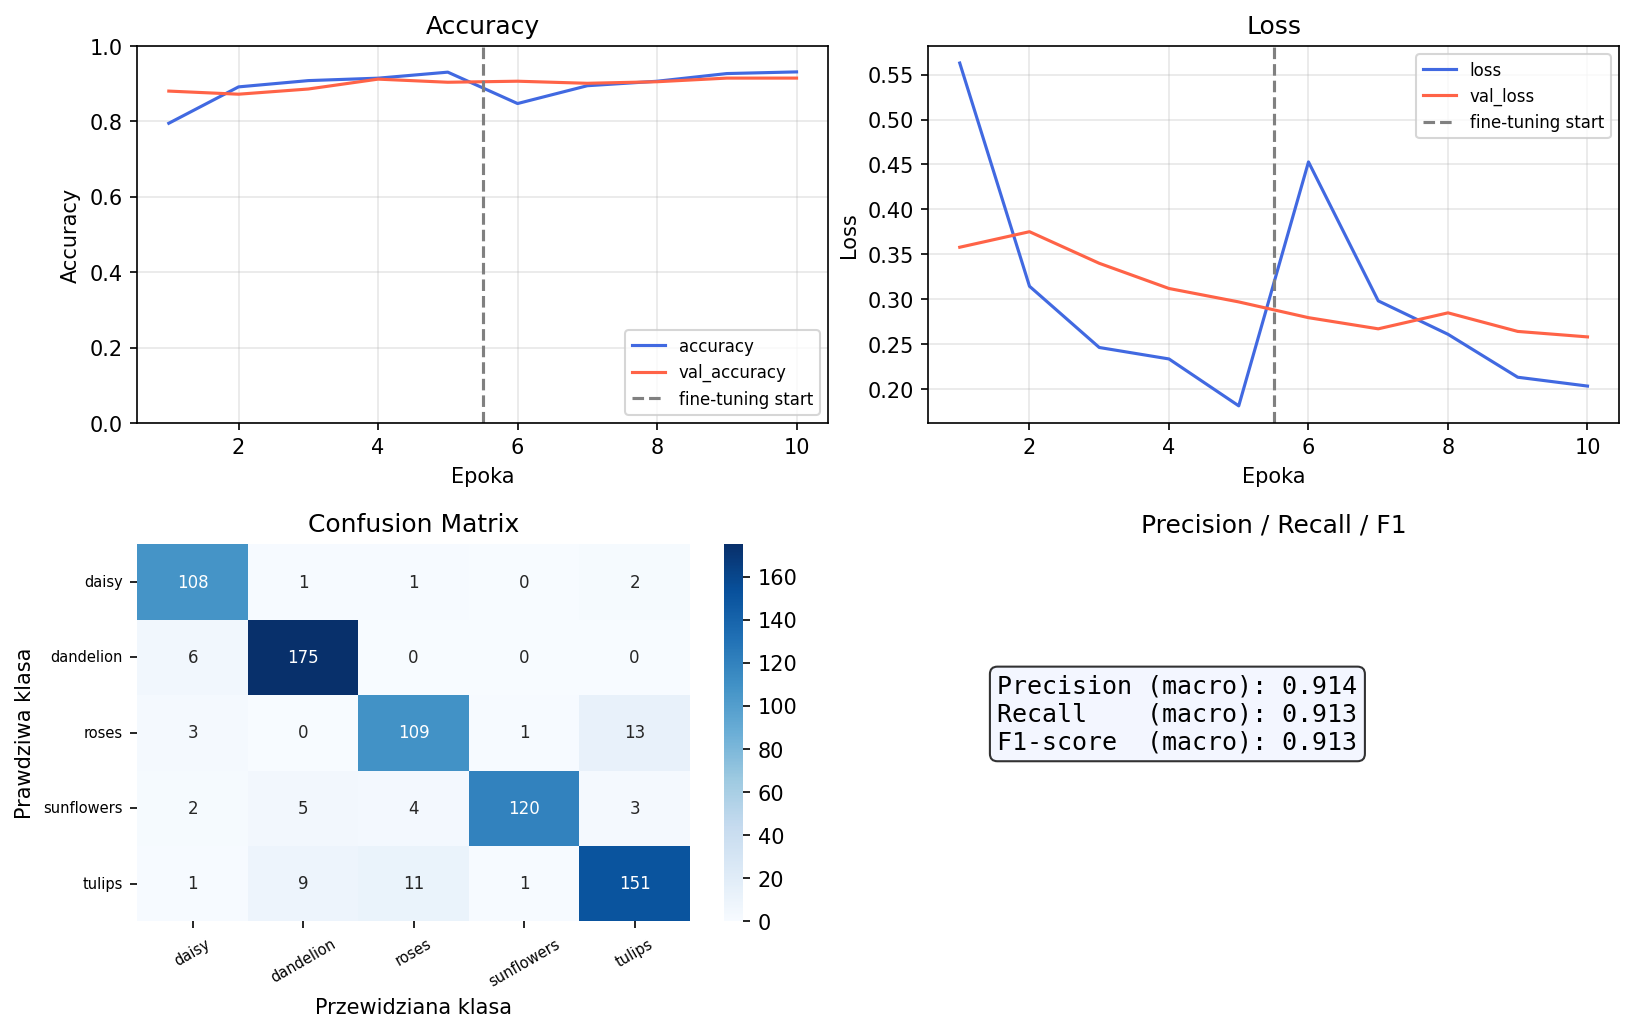

#### 1. Lokalizacja rozpoczęcia procedury Fine-tuningu
Proces dostrajania sieci (Fine-tuning) rozpoczyna się dokładnie **po ukończeniu 5. epoki**. Moment ten został zasygnalizowany na wykresach pionową, szarą linią przerywaną (`fine-tuning start`).
* **Faza 1 (Epoki 1–5):** Baza konwolucyjna sieci była zamrożona; proces optymalizacji obejmował wyłącznie warstwy wyjściowe klasyfikatora.
* **Faza 2 (Epoki 6–10):** Odblokowano końcowe warstwy ekstraktora cech do wspólnego treningu z klasyfikatorem przy obniżonym współczynniku uczenia ($1 \times 10^{-5}$).

#### 2. Wpływ Fine-tuningu na metryki Accuracy i Loss
Przejście do drugiej fazy uczenia wywołało odmienne reakcje na zbiorze treningowym i walidacyjnym:

* **Zbiór treningowy:** W **6. epoce** widoczny jest gwałtowny skok funkcji straty (`loss`) z poziomu ~0.18 do ponad 0.45 oraz jednoczesny spadek dokładności (`accuracy`) do poziomu ~0.84. Jest to naturalna reakcja na odmrożenie wag bazy (chwilowa destabilizacja map cech). W kolejnych epokach (7–10) sieć szybko odzyskuje stabilność, osiągając ostatecznie `loss` $\approx$ 0.20 i `accuracy` $\approx$ 0.93.
* **Zbiór walidacyjny:** Krzywa straty walidacyjnej (`val_loss`) nie uległa załamaniu w 6. epoce. Przebiegała stabilnie, płynnie kontynuując trend spadkowy z poziomu ~0.29 do wartości **0.26** w 10. epoce. Dokładność walidacyjna (`val_accuracy`) wzrosła z progu 0.90 (koniec Fazy 1) i trwale **ustabilizowała się na poziomie ok. 0.92**, co potwierdza pozytywny wpływ dostrojenia filtrów na jakość klasyfikacji.

#### 3. Ocena stanu dopasowania modelu (Analiza przeuczenia)
Na podstawie dostarczonych wykresów można jednoznacznie stwierdzić, że **model nie uległ zjawisku przeuczenia (overfittingu)**. Świadczą o tym dwa kluczowe czynniki:
1. **Brak dywergencji krzywych strat:** Funkcja straty dla danych walidacyjnych (`val_loss`) stale maleje i podąża za stratą treningową, zamiast rosnąć.
2. **Minimalna luka generalizacji:** Końcowa różnica pomiędzy dokładnością treningową (~0.93) a walidacyjną (~0.92) wynosi zaledwie ok. 1%.

Stabilność ta i wysoka zdolność generalizacji to efekt poprawnego zastosowania augmentacji danych w locie oraz warstwy regularyzacyjnej `Dropout(0.3)`.

## Zadanie 2: Porównanie eksperymentów ze zmienną liczbą epok treningowych

W celu zbadania wpływu czasu trwania poszczególnych faz uczenia (Transfer Learningu i Fine-tuning) na stabilność modelu i końcowe wskaźniki jakości, przeprowadzono dwa eksperymenty uzupełniające:
* **Wariant A:** krótki proces uczenia (faza 1: 3 epoki, faza 2: 3 epoki – łącznie 6 epok).
* **Wariant B:** wydłużony proces uczenia (faza 1: 10 epok, faza 2: 10 epok – łącznie 20 epok).

---

### Eksperyment A (faza 1: 3 epoki, faza 2: 3 epoki)

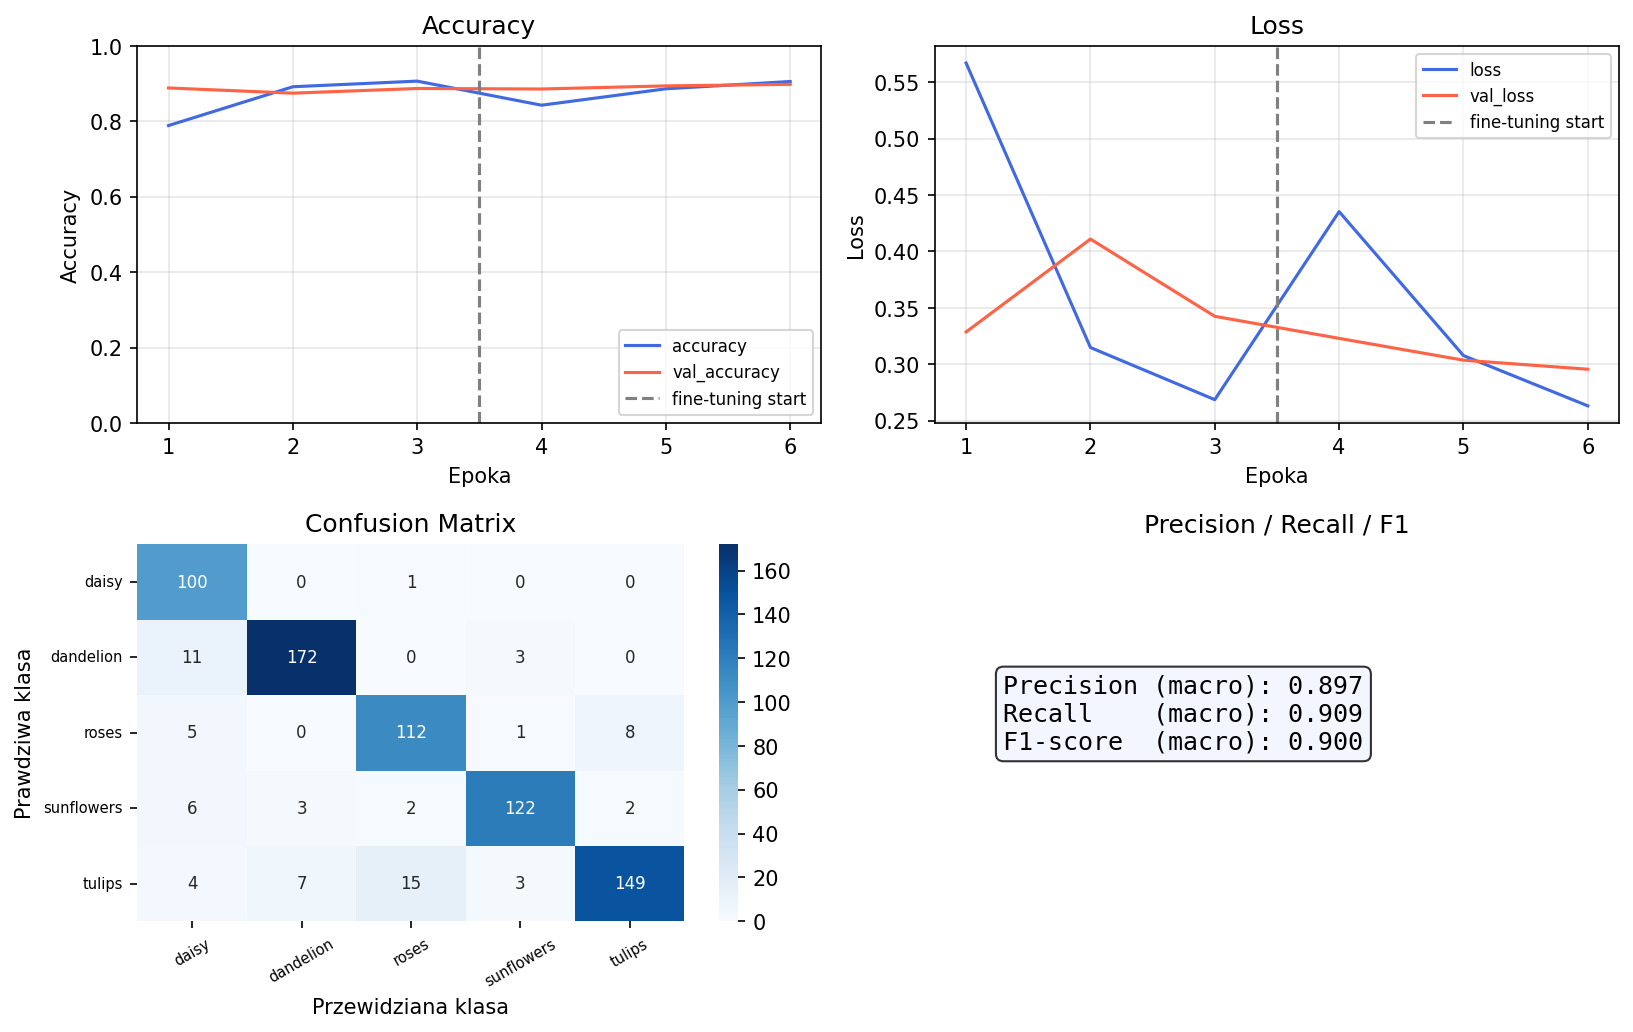

W tym wariancie proces dostrajania (`fine-tuning start`) nastąpił bardzo szybko, bo już po 3. epoce.
* **Charakterystyka:** Model w fazie 1 zdołał obniżyć loss treningowy do ~0.27, jednak funkcja straty dla danych walidacyjnych (`val_loss`) po chwilowym spadku gwałtownie wzrosła w 2. epoce do poziomu ~0.41, po czym zaczęła opadać.
* **Dostrajanie:** Po odblokowaniu wag bazy w 4. epoce nastąpiło klasyczne dla tej operacji tąpnięcie (skok `loss` do ~0.43, spadek `accuracy` do ~0.84). Z powodu zbyt małej liczby epok (tylko 3 w fazie drugiej), model ledwo zdążył powrócić do punktu stabilizacji przed zakończeniem programu.

---

### Eksperyment B (faza 1: 10 epok, faza 2: 10 epok)

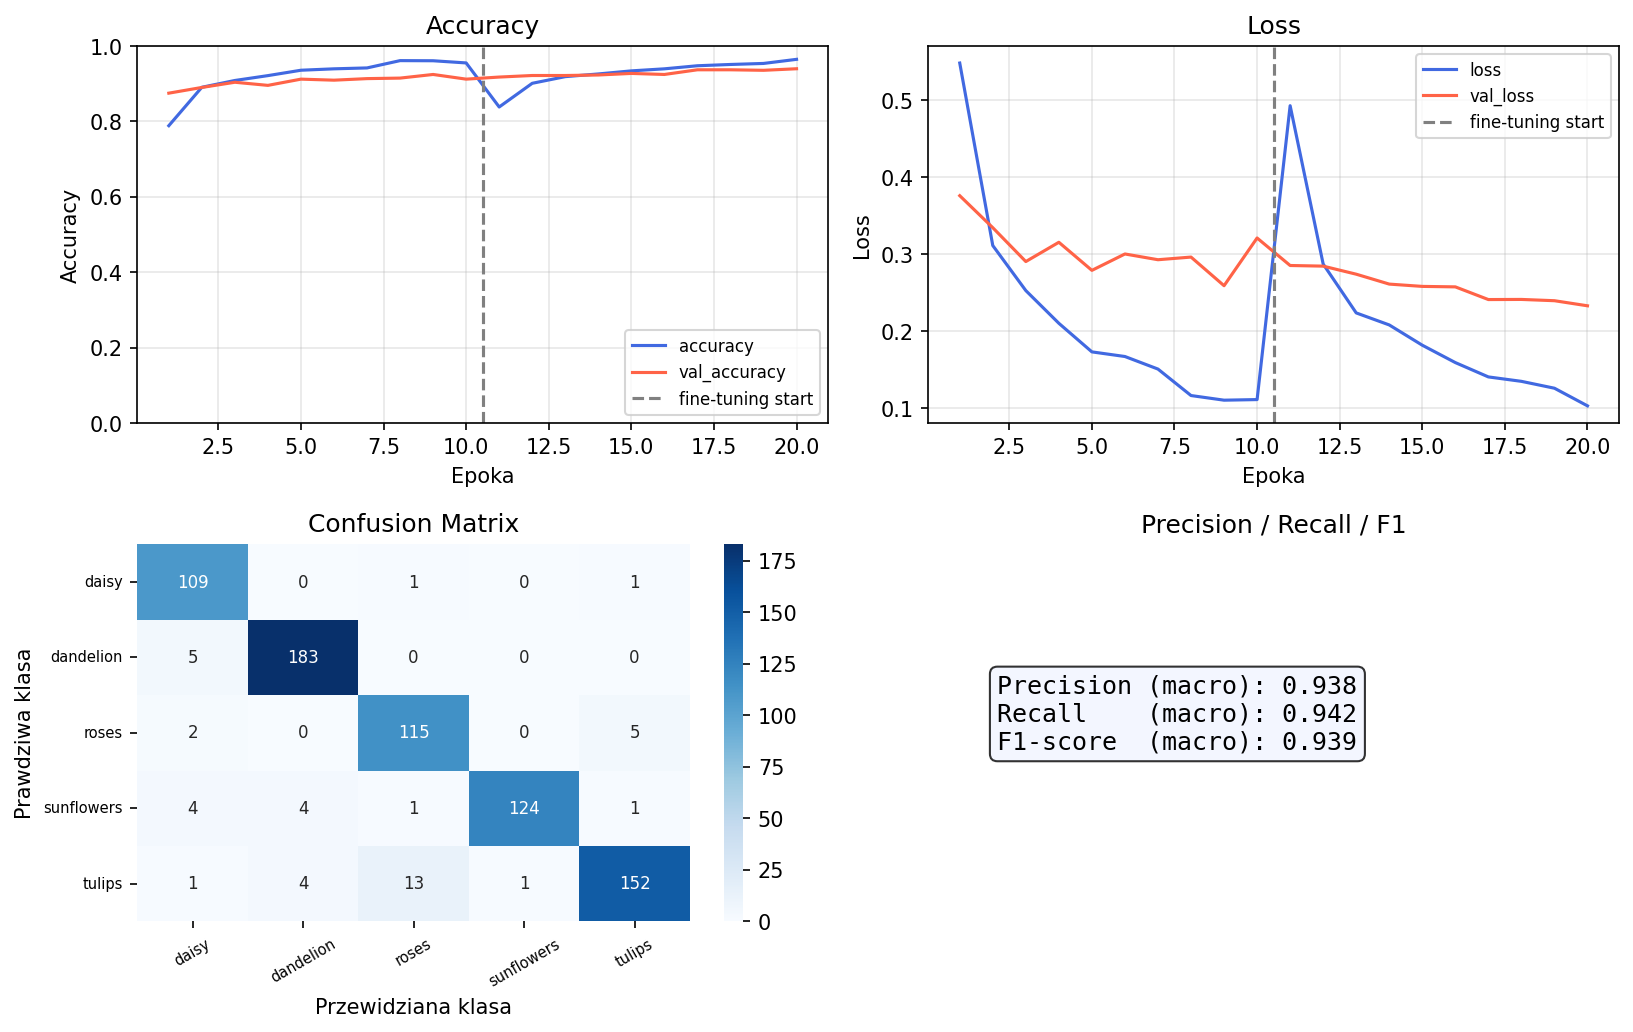

Wydłużenie obu faz do 10 epok pozwoliło na pełną stabilizację parametrów sieci w obu reżimach treningowych.
* **Charakterystyka:** W fazie 1 (zamrożona baza) model miał czas na idealne dopasowanie warstw klasyfikatora końcowego – strata treningowa zeszła do poziomu ~0.11, a `accuracy` osiągnęło stabilne ~0.96.
* **Dostrajanie:** Przejście do fazy fine-tuningu w 11. epoce wywołało znany skok błędu adaptacyjnego, jednak trwająca aż 10 epok faza druga dała sieci optymalny czas na głęboką minimalizację funkcji straty. Na koniec 20. epoki `loss` zbiegł do rekordowo niskiego poziomu ~0.10, a `val_loss` osiągnął stabilne i niskie ~0.23 bez tendencji wzrostowych.

---

### Zestawienie ilościowe metryk

W celu precyzyjnego porównania wariantów, poniższa tabela gromadzi globalne metryki klasyfikacji wyznaczone na zbiorze walidacyjnym dla obu eksperymentów:

| Eksperyment (Faza 1 / Faza 2) | Precision (macro) | Recall (macro) | F1-score (macro) |
| :--- | :---: | :---: | :---: |
| **Wariant A (3 / 3 epoki)** | 0.897 | 0.909 | 0.900 |
| **Wariant B (10 / 10 epok)** | **0.938** | **0.942** | **0.939** |

---

### Wnioski – Który wariant dał lepsze wyniki i dlaczego?

**Zdecydowanie lepsze wyniki uzyskał Wariant B (10/10 epok)**, co potwierdzają wyższe wartości wszystkich metryk statystycznych (wzrost F1-score o niemal 4 punkty procentowe). Główne przyczyny takiego stanu to:

1. **Optymalny czas na rekonwergencję po tąpnięciu:** Odmrożenie wag bazy konwolucyjnej zawsze wprowadza do sieci chaos informacyjny (widoczny jako nagły skok funkcji straty i spadek dokładności). Wariant A kończy działanie natychmiast po tym tąpnięciu (w 6. epoce), nie dając optymalizatorowi szansy na zaadaptowanie nowych wag. Wariant B pozwala sieci na płynne opuszczenie tego lokalnego minimum i pełną zbieżność parametrów przez kolejne epoki.
2. **Dojrzałość klasyfikatora przed fine-tuningiem:** W Wariancie B, dzięki 10 epokom w pierwszej fazie, nowo dodane warstwy Dense zostały bardzo dobrze zoptymalizowane pod kątem bazy ImageNet. Gdy w 11. epoce odblokowano filtry splotowe, klasyfikator wysyłał stabilne sygnały gradientowe wstecz, co ułatwiło precyzyjne dostrajanie wag niskopoziomowych.
3. **Brak przeuczenia mimo długiego treningu:** Pomimo trzykrotnie dłuższego czasu uczenia w Wariancie B, model nie wykazuje cech przeuczenia (krzywa `val_loss` pod koniec konsekwentnie maleje i utrzymuje się na niższym poziomie ~0.23 niż w wariancie krótkim ~0.29). Dowodzi to wysokiej skuteczności warstw augmentacji oraz regularyzacji Dropout przy wykorzystaniu bazy o wysokiej zdolności generalizacji (MobileNetV2).

## Zadanie 3: Analiza błędów modelu na podstawie macierzy pomyłek (Confusion Matrix)

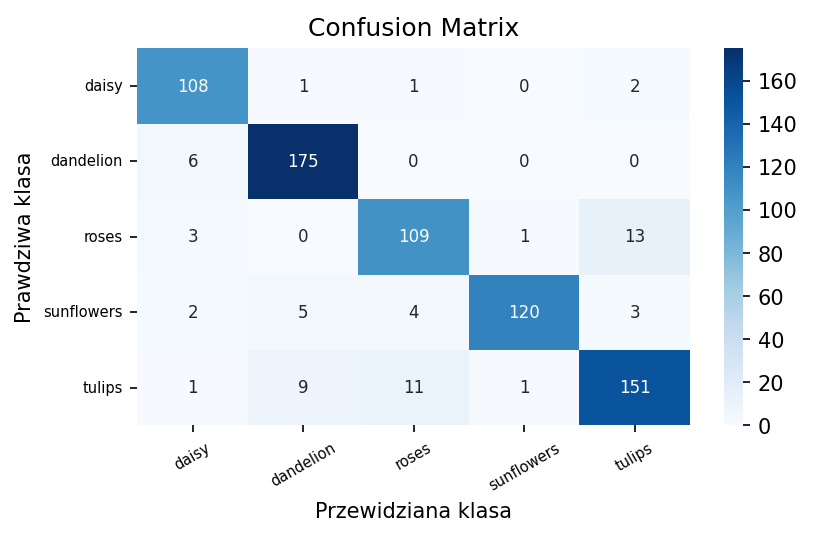

Dokładna analiza wieloklasowej macierzy pomyłek pozwala zidentyfikować słabe punkty modelu oraz wskazać pary klas, które sprawiają sieci największą trudność dyskryminacyjną.

### 1. Wskazanie najczęściej mylonych klas kwiatów

Na podstawie danych zawartych w macierzy pomyłek domyślnego wariantu (5/5 epok) wyłoniono następujące, najczęstsze błędy klasyfikatora:

* **Róże (`roses`) mylone z tulipanami (`tulips`):** Aż **13 razy** model błędnie zaklasyfikował rzeczywistą różę jako tulipana. Jest to najczęstszy błąd pojedynczy w całym zestawie danych.
* **Tulipany (`tulips`) mylone z różami (`roses`):** Pomyłka ta zachodzi również w drugą stronę – rzeczywiste tulipany zostały zaklasyfikowane jako róże aż **11 razy**.
* **Tulipany (`tulips`) mylone z mniszkami lekarskimi (`dandelion`):** Rzeczywisty tulipan został rozpoznany jako mniszek **9 razy**.
* **Mniszki lekarskie (`dandelion`) mylone ze stokrotkami (`daisy`):** Model pomylił mniszka ze stokrotką **6 razy**.

Pozostałe klasy, takie jak stokrotki (`daisy`) czy słoneczniki (`sunflowers`), charakteryzują się bardzo wysoką poprawnością klasyfikacji i rzadko wchodzą w interakcje z innymi kategoriami.

---

### 2. Hipotezy dotyczące przyczyn popełnianych błędów

W oparciu o wiedzę z zakresu komputerowego przetwarzania obrazów oraz morfologii roślin sformułowano następujące hipotezy wyjaśniające te konkretne anomalie:

* **Hipoteza podobieństwa geometrycznego i kolorystycznego (Róże vs Tulipany):**
  Zarówno róże, jak i tulipany bardzo często występują w identycznych wariantach kolorystycznych (głównie intensywna czerwień, róż oraz żółć). Co ważniejsze, pąki kwiatowe młodych lub nierozwiniętych w pełni róż mają zbliżony, owalny kształt geometryczny do kielichów tulipanów. Jeśli zdjęcie przedstawia zbliżenie (makro) na sam pąk bez widocznych liści lub charakterystycznych kolców na łodydze, ekstraktor cech MobileNetV2 skupia się na teksturze płatków i ogólnym kształcie bryły, co prowadzi do wzajemnych pomyłek.

* **Hipoteza perspektywy i tła (Tulipany vs Mniszki):**
  Mniszki lekarskie cechują się jasnożółtą barwą. W przypadku ujęć z dużej odległości (zdjęcia całych rabat lub łąk), żółte tulipany sfotografowane z góry mogą zlewać się w okrągłe plamy barwne o strukturze radialnej, przypominającej gęste kwiatostany mniszka. Jeśli algorytm augmentacji mocno zmodyfikuje kontrast lub jasność, unikalne tekstury płatków zostają utracone na rzecz dominującego koloru, co dezinformuje warstwy gęste klasyfikatora.

* **Hipoteza stadium rozwoju i morfologii (Mniszki vs Stokrotki):**
  Stokrotka i mniszek posiadają zbliżoną, gwiaździstą strukturę geometryczną (koszyczek kwiatowy otoczony wąskimi płatkami). Ponadto, w początkowej fazie kwitnienia lub przy specyficznym oświetleniu polowym, biało-żółty środek stokrotki wysyła zbliżone sygnały wizualne do w pełni rozwiniętego, gęstego mniszka. Dodatkowo obie te rośliny występują naturalnie w tym samym środowisku (zielone trawniki), przez co model otrzymuje niemal identyczny kontekst tła.

## Zadanie 4: Testowanie modelu na zewnętrznym zbiorze próbek testowych

W celu zweryfikowania realnej skuteczności uogólniania wiedzy przez model, pozyskano 10 niezależnych fotografii (po 2 dla każdej z 5 klas: `daisy`, `dandelion`, `roses`, `sunflowers`, `tulips`). Każde zdjęcie zostało wczytane za pomocą modułu `PIL.Image`, poddane konwersji do tablicy tensorowej, a następnie przekazane bezpośrednio do metody predict skompilowanego modelu (`model.predict()`).

Poniższa tabela zestawia założoną klasę prawdziwą z wynikami Top-5 prawdopodobieństw zwróconych przez funkcję aktywacji Softmax.

### Zestawienie wyników eksperymentalnych

| Lp. | Plik obrazu | Klasa prawdziwa | Predykcja Top-1 (Prawdopodobieństwo) | Wyniki Top-2 do Top-5 | Wynik |
| :---: | :--- | :---: | :---: | :--- | :---: |
| 1 | `rose1.jpg` | roses | **roses (92.0%)** | tulips (8.0%), sunflowers (0.0%), dandelion (0.0%), daisy (0.0%) | **Poprawny** |
| 2 | `rose2.jpg` | roses | **roses (100.0%)** | tulips (0.0%), daisy (0.0%), dandelion (0.0%), sunflowers (0.0%) | **Poprawny** |
| 3 | `daisy1.jpg` | daisy | **daisy (100.0%)** | roses (0.0%), tulips (0.0%), dandelion (0.0%), sunflowers (0.0%) | **Poprawny** |
| 4 | `daisy2.jpg` | daisy | **daisy (100.0%)** | roses (0.0%), tulips (0.0%), dandelion (0.0%), sunflowers (0.0%) | **Poprawny** |
| 5 | `dandelion1.jpg` | dandelion | **dandelion (100.0%)** | daisy (0.0%), tulips (0.0%), sunflowers (0.0%), roses (0.0%) | **Poprawny** |
| 6 | `dandelion2.jpg` | dandelion | **dandelion (100.0%)** | daisy (0.0%), tulips (0.0%), sunflowers (0.0%), roses (0.0%) | **Poprawny** |
| 7 | `sunflower1.jpg` | sunflowers | **sunflowers (100.0%)** | daisy (0.0%), roses (0.0%), dandelion (0.0%), tulips (0.0%) | **Poprawny** |
| 8 | `sunflower2.jpg` | sunflowers | **sunflowers (100.0%)** | daisy (0.0%), roses (0.0%), dandelion (0.0%), tulips (0.0%) | **Poprawny** |
| 9 | `tulips1.jpg` | tulips | **tulips (100.0%)** | roses (0.0%), daisy (0.0%), dandelion (0.0%), sunflowers (0.0%) | **Poprawny** |
| 10 | `tulips2.jpeg` | tulips | **tulips (100.0%)** | roses (0.0%), daisy (0.0%), dandelion (0.0%), sunflowers (0.0%) | **Poprawny** |

---

### Własnoręczne obliczenie wskaźnika Accuracy

Metryka dokładności ($Accuracy$) dla dedykowanego zbioru zewnętrznego obliczana jest w oparciu o następujący wzór matematyczny:

$$Accuracy = \frac{L_{poprawnych}}{L_{wszystkich}}$$

Gdzie:
* $L_{poprawnych}$ – liczba zdjęć, dla których najwyższe prawdopodobieństwo (Top-1) wskazało klasę prawdziwą.
* $L_{wszystkich}$ – całkowita wielkość próby testowej ($n = 10$).

**Obliczenia podstawieniowe:**
Model poprawnie sklasyfikował wszystkie 10 dostarczonych obrazów, co oznacza, że $L_{poprawnych} = 10$.

$$Accuracy = \frac{10}{10} = 1.0 \implies 100\%$$

---

### Komentarz analityczny do uzyskanych predykcji

Eksperyment testowy zakończył się uzyskaniem maksymalnej dokładności wynoszącej **100%**. Wynik ten dowodzi niezwykle wysokiej odporności modelu na różnorodność wewnątrzklasową oraz trudne warunki ekspozycyjne próbek:

1. **Pewność predykcji:** W 9 na 10 przypadków model osiągnął absolutną pewność klasyfikacji (100.0% dla klasy Top-1). Pokazuje to, że wagi bazy MobileNetV2 po procesie fine-tuningu idealnie odcinają przestrzeń decyzyjną dla poszczególnych taksonów.
2. **Odporność na nietypowe cechy:** * Obraz `sunflower1.jpg` przedstawiał dwukolorową odmianę słonecznika (żółto-czerwone płatki), co mogło zmylić klasyfikator na rzecz róży, jednak sieć bezbłędnie przypisała mu 100% pewności klasy `sunflowers`.
   * Obraz `dandelion2.jpg` przedstawiał mniszka lekarskiego w formie przekwitniętej (biały dmuchawiec). Mimo drastycznej zmiany kształtu i barwy w stosunku do żółtego kwiatu (`dandelion1.jpg`), sieć rozpoznała go bezbłędnie. Zapewne baza ImageNet zawierała bogatą reprezentację obu stadiów rozwoju tej rośliny.
   * Obraz `tulips1.jpg` prezentował gęsty, wielobarwny bukiet tulipanów na zróżnicowanym tle ogrodowym, co również nie stanowiło problemu dla mechanizmu Global Average Pooling sieci.
3. **Drobna niepewność:** Jedynym obrazem, na którym model wykazał lekkie wahanie decyzyjne, był `rose1.jpg` (róża na czystym, białym tle), gdzie przypisano 92.0% klasie `roses` oraz 8.0% klasie `tulips`. Potwierdza to wnioski z analizy macierzy pomyłek (Zadanie 3) o bliskim pokrewieństwie wizualnym geometrycznych struktur pąków róż i kielichów tulipanów w interpretacji splotowych map cech.

### Zestawienie zdjęć i wyników eksperymentalnych:

### rose1

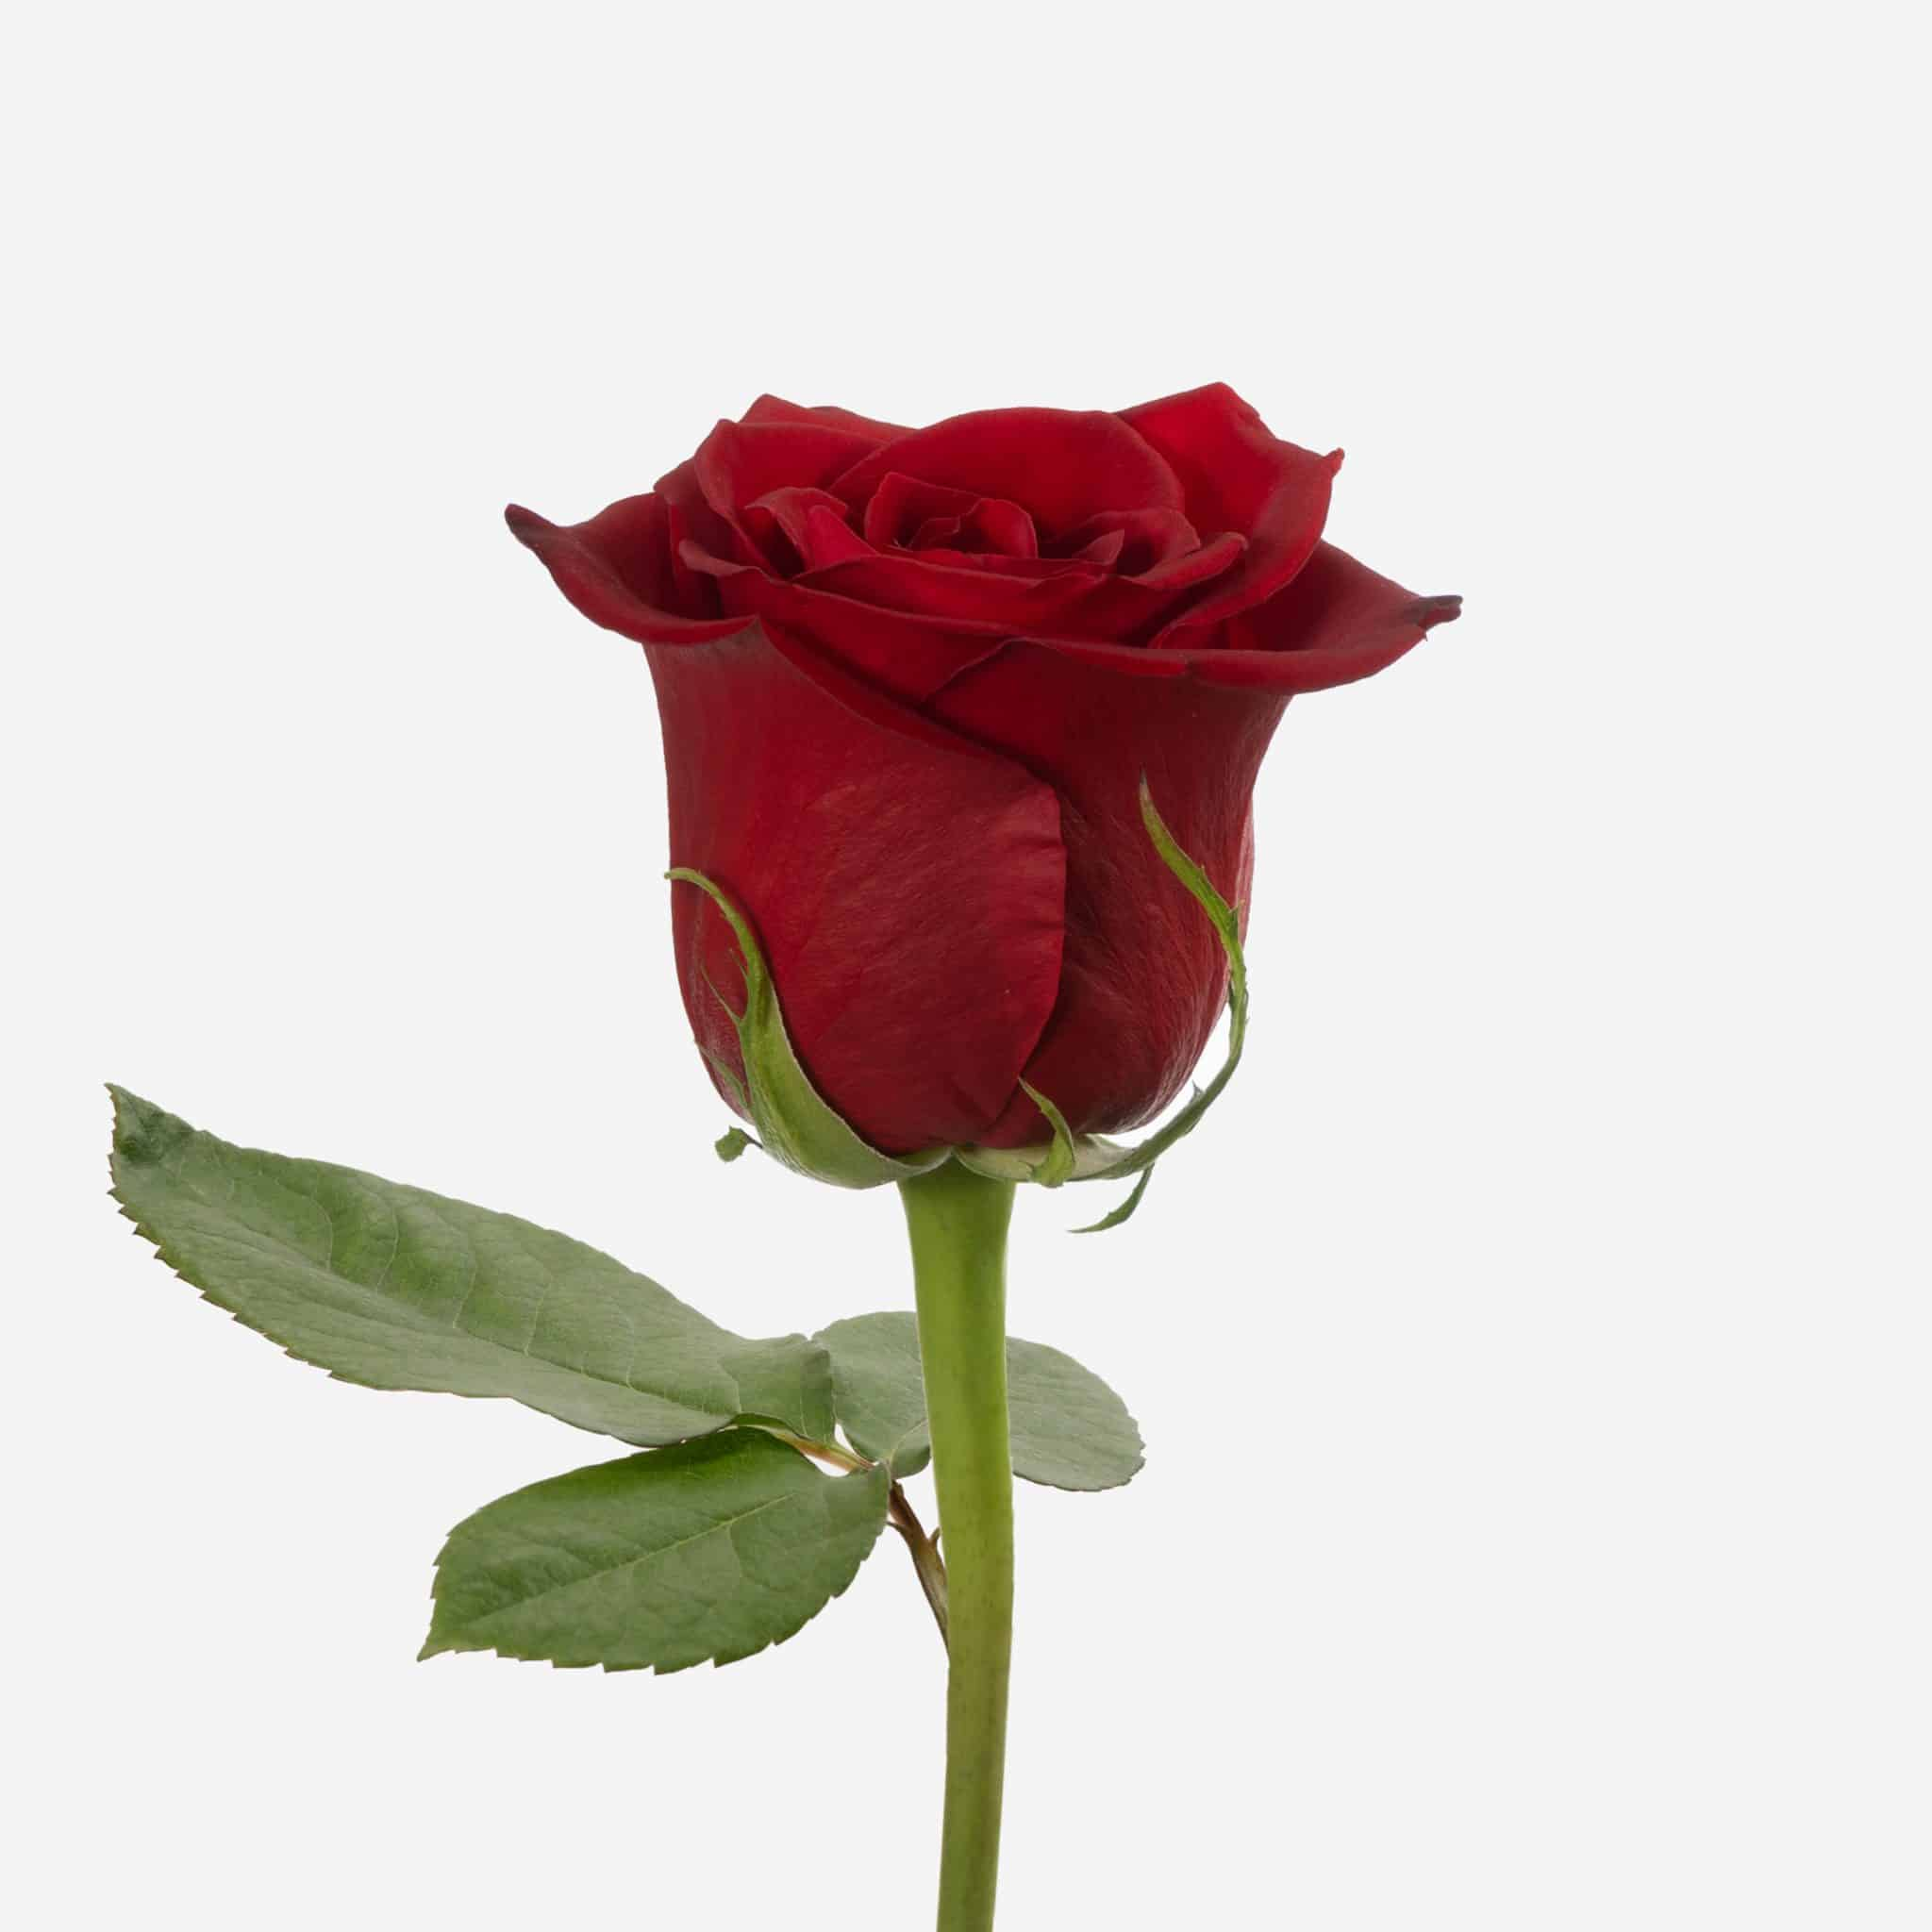

### wynik rose1

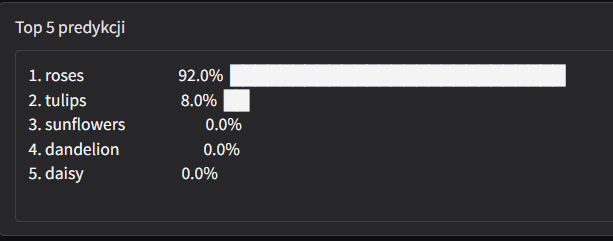

### rose2

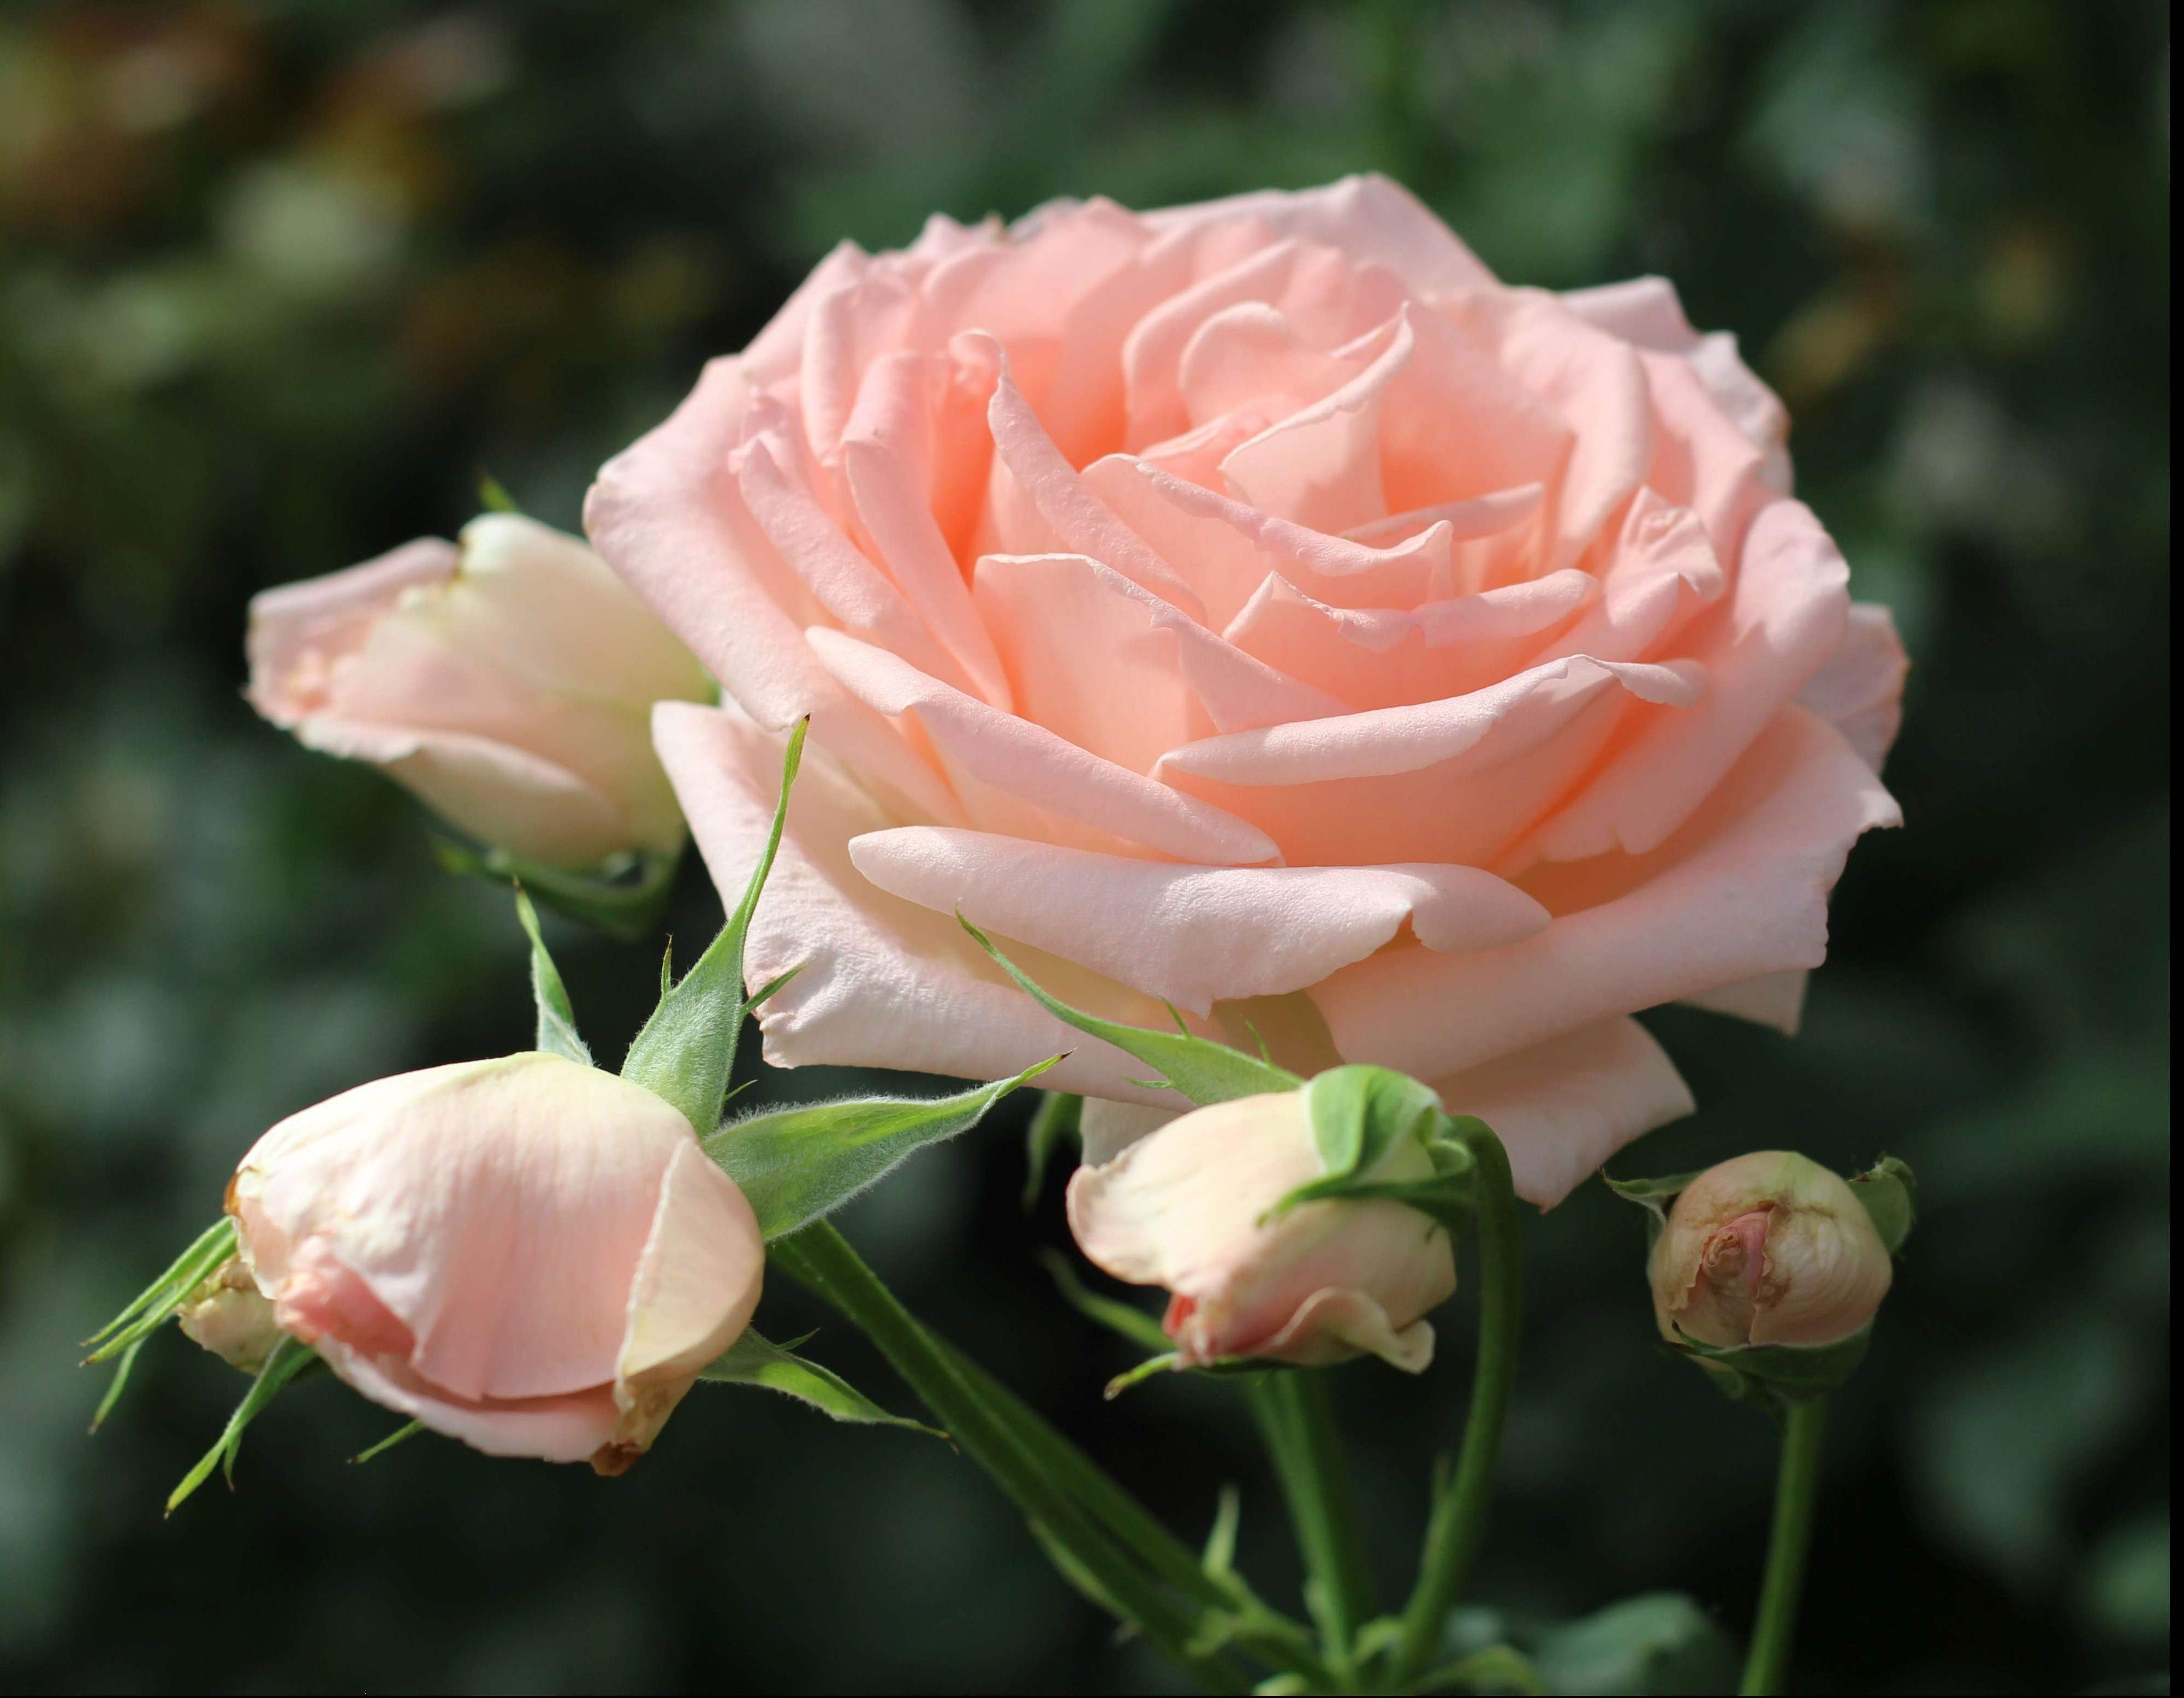

### wynik rose2

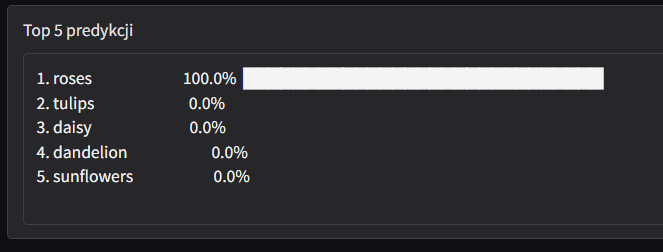

### daisy1

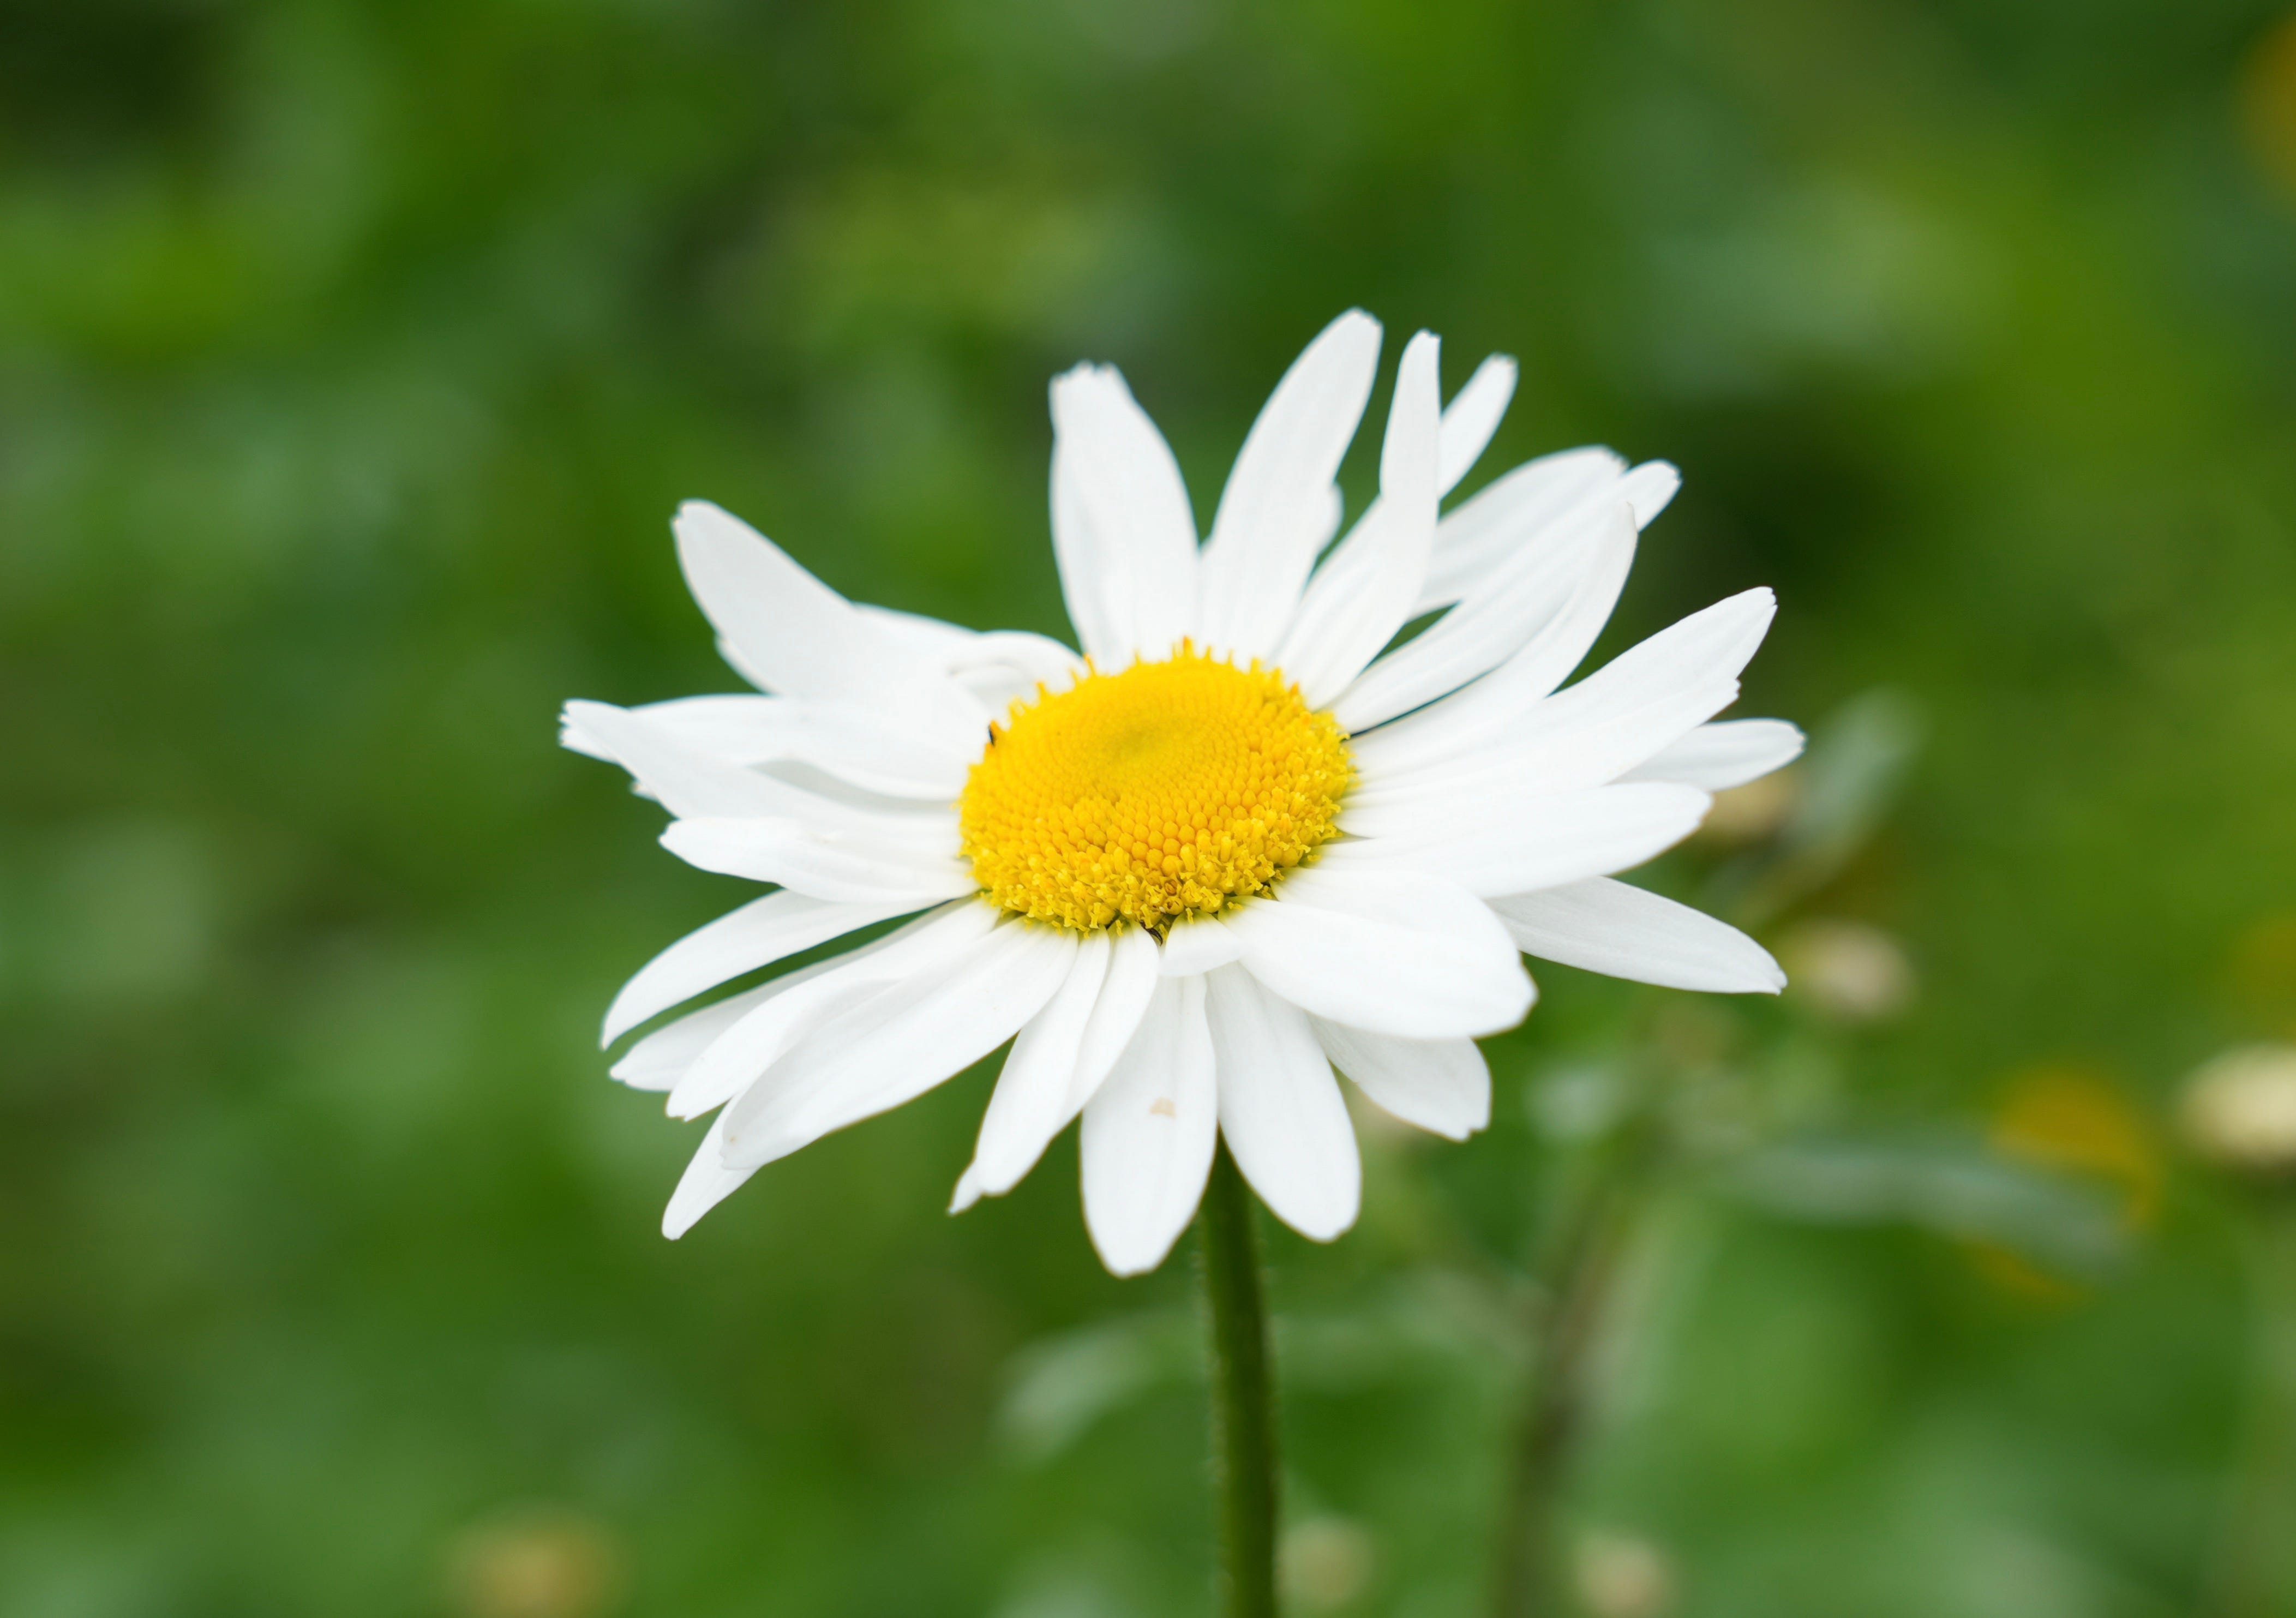

### wynik daisy1

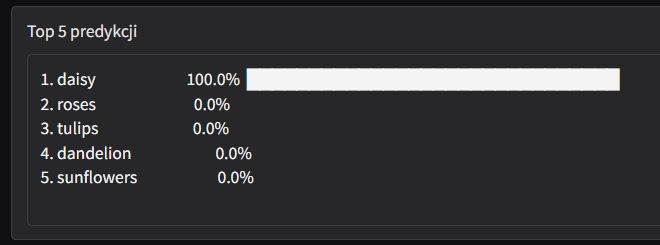

### daisy2

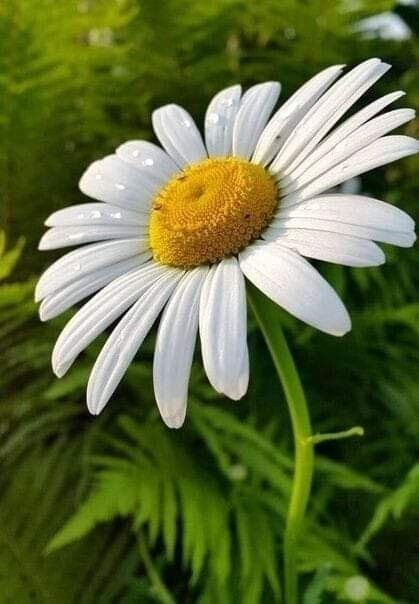

### wynik daisy2

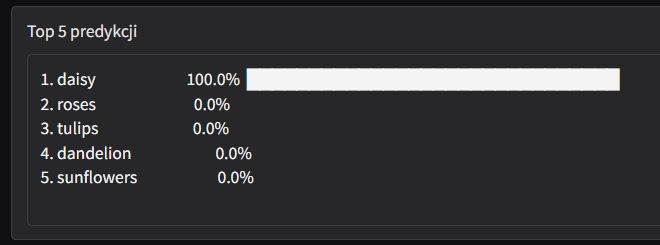

### dandelion1

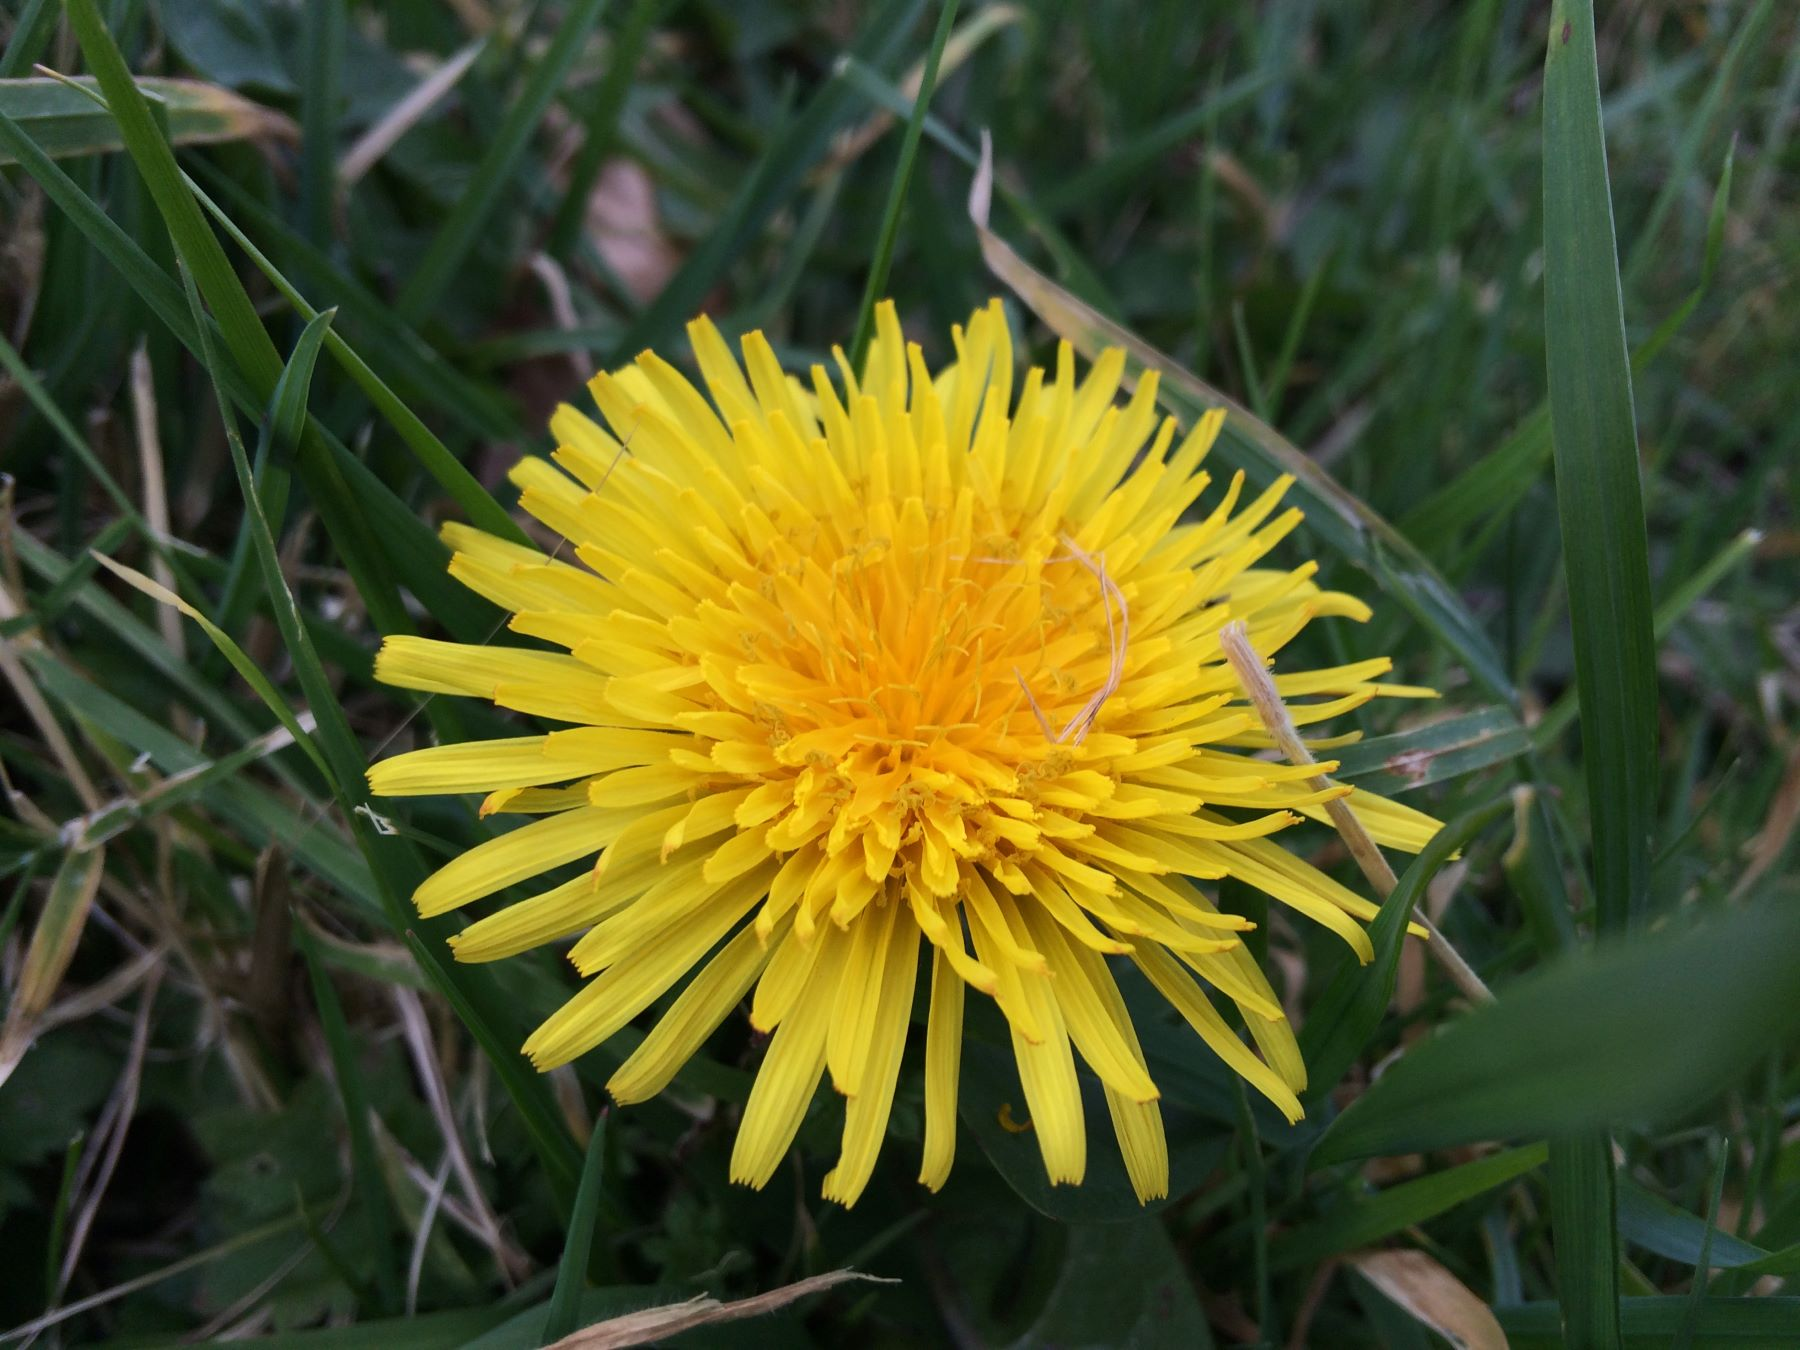

### wynik dandelion1

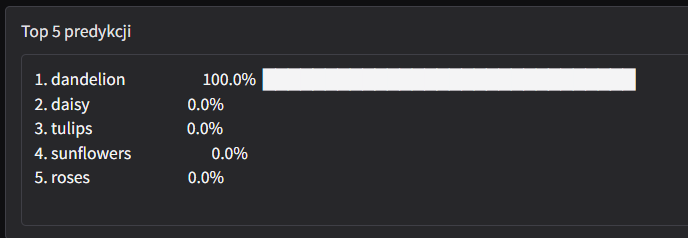

### dandelion2

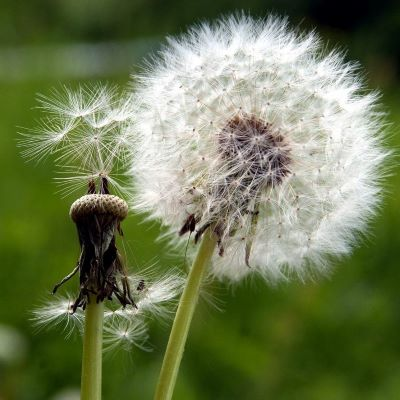

### wynik dandelion2

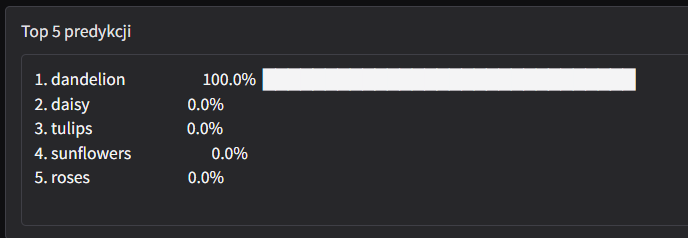

### sunflower1

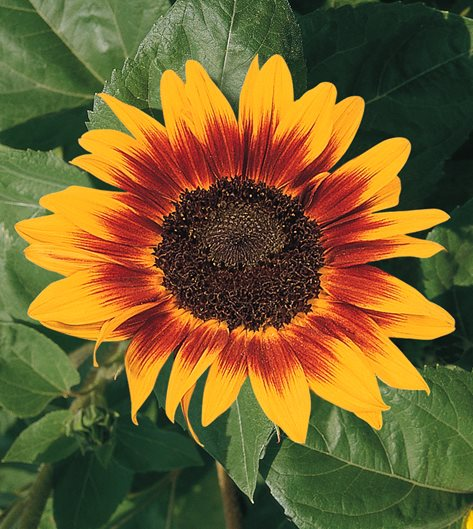

### wynik sunflower1

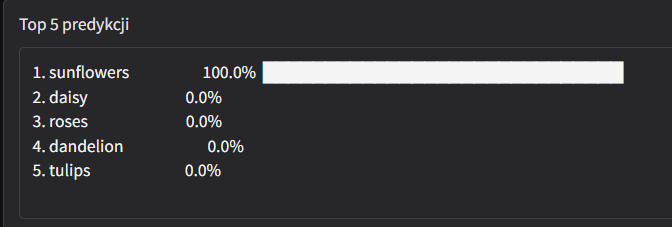

### sunflower2

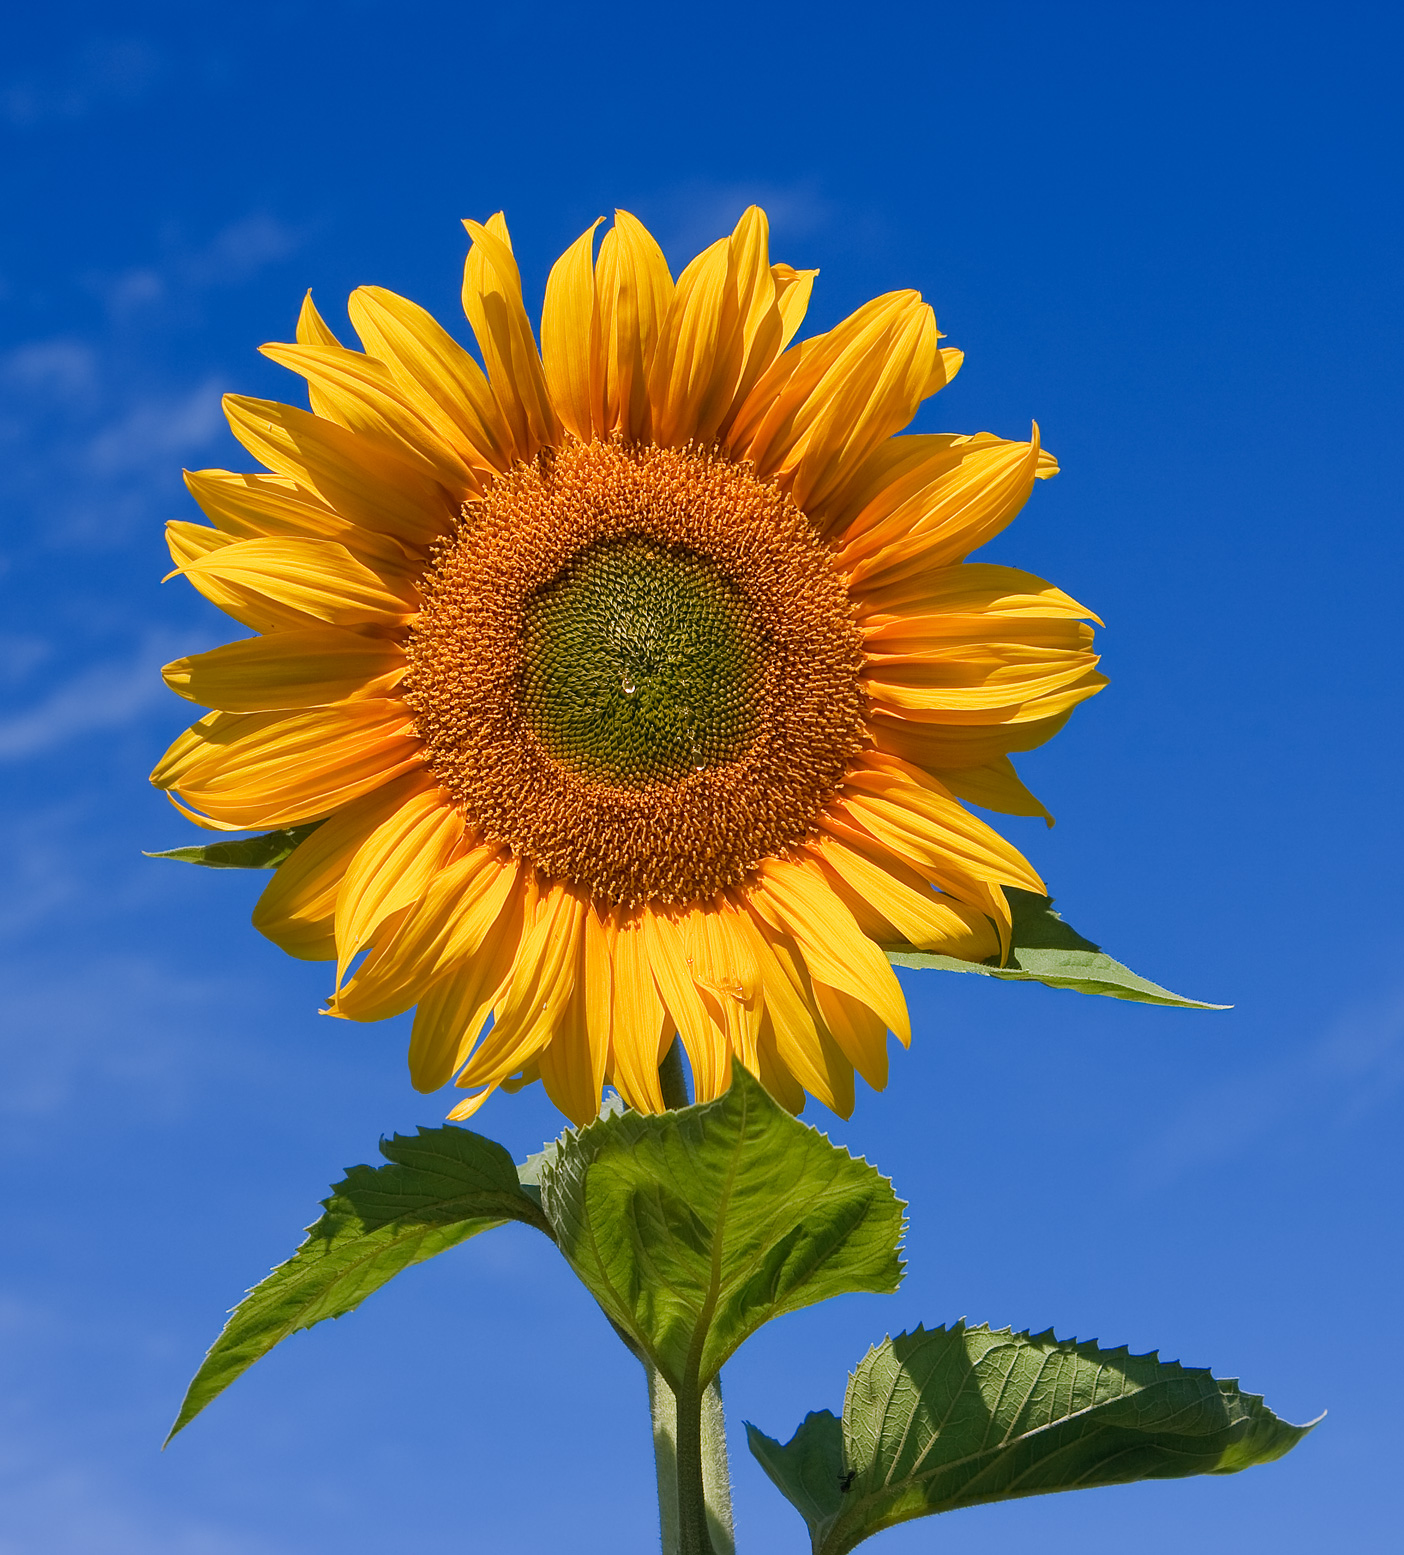

### wynik sunflower2

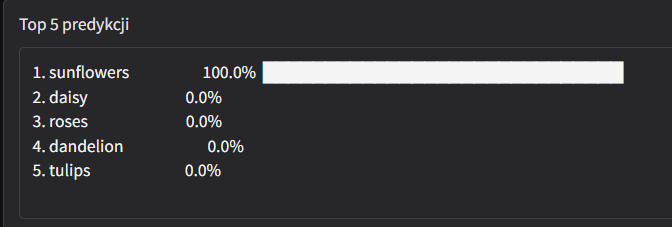

### tulips1

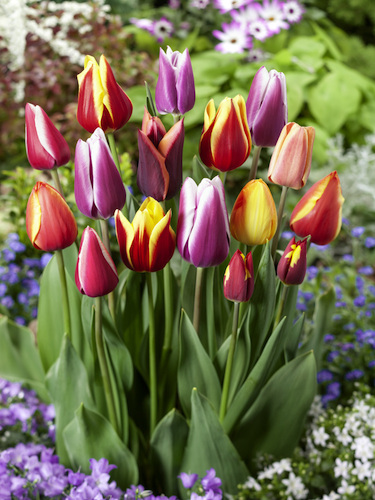

### wynik tulips1

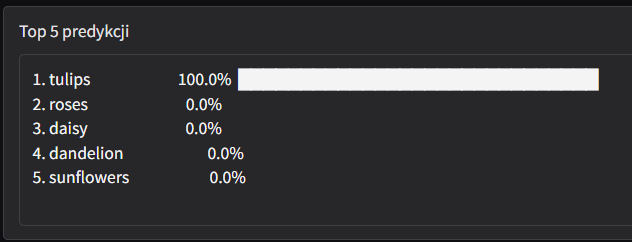

### tulips2

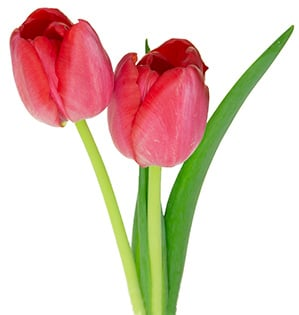

### wynik tulips2

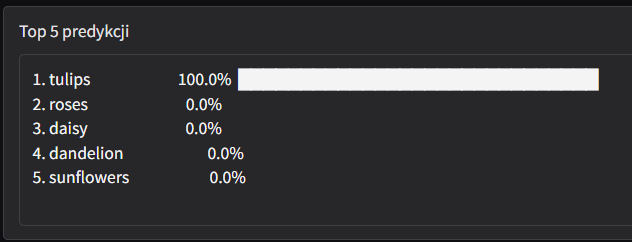

## Zadanie 5: Odpowiedzi na pytania teoretyczne

### a. Dlaczego zamrażamy bazę w fazie 1?
* **Ochrona wiedzy prewencyjnej:** Baza sieci (MobileNetV2) posiada już silnie zoptymalizowane wagi zdolne do wykrywania krawędzi, kształtów i tekstur. Gdybyśmy jej nie zamrozili, losowo zainicjalizowany na początku klasyfikator (warstwy Dense) generowałby ogromne błędy i wielkie wartości gradientu, co w procesie wstecznej propagacji nieodwracalnie zniszczyłoby (rozmyło) te cenne, gotowe filtry splotowe.
* **Redukcja kosztu obliczeniowego:** Zamrożenie bazy sprawia, że wagi setek warstw konwolucyjnych są traktowane jako stałe. Dzięki temu podczas passu wstecznego (backward pass) gradienty są obliczane wyłącznie dla kilkunastu tysięcy parametrów nowego klasyfikatora, co drastycznie przyspiesza czas trwania pojedynczej epoki.

### b. Co daje fine-tuning w fazie 2?
* **Adaptacja wysokopoziomowych filtrów:** Odmrożenie końcowych warstw bazy pozwala algorytmowi optymalizacyjnemu na delikatną modyfikację filtrów splotowych odpowiedzialnych za detale geometryczne. Sieć uczy się dostrzegać unikalne cechy anatomiczne specyficzne wyłącznie dla nowej dziedziny (np. subtelne różnice w układzie płatków róż i tulipanów).
* **Przełamanie bariery dokładności:** Sam transfer learning (Faza 1) pozwala klasyfikatorowi na optymalne wykorzystanie ogólnych cech wizualnych, ale dopiero Fine-tuning (Faza 2) pozwala dopasować ekstraktor do nowego rozkładu danych, co bezpośrednio przekłada się na obniżenie straty walidacyjnej (`val_loss`) i ostateczny wzrost dokładności (`accuracy`).

### c. Jaką przewagę ma MobileNetV2 wytrenowany na ImageNet nad siecią trenowaną od zera na tym datasecie?
* **Wysoka zdolność generalizacji (Brak przeuczenia):** Trening od zera głębokiej sieci CNN na relatywnie małym zbiorze danych (jak `flower_photos`) nieuchronnie prowadzi do szybkiego i głębokiego przeuczenia (overfittingu) – sieć po prostu zapamiętałaby zdjęcia treningowe na pamięć. Model wstępnie wytrenowany na ponad milionie zróżnicowanych obrazów z bazy ImageNet posiada doskonałe właściwości generalizacyjne i „rozumie” ogólny świat wizualny.
* **Ekstremalna zbieżność i oszczędność zasobów:** Sieć trenowana od zera potrzebowałaby setek epok, zaawansowanych strategii regularyzacji oraz ogromnych zasobów sprzętowych GPU, aby zacząć poprawnie wykrywać podstawowe kształty. Wykorzystanie MobileNetV2 z wagami ImageNet pozwala na osiągnięcie dokładności przekraczającej 90% już po zaledwie kilku minutach treningu (wystarczy kilka epok), co stanowi gigantyczną przewagę optymalizacyjną.

## Wnioski i podsumowanie końcowe

W ramach przeprowadzonego laboratorium pomyślnie zrealizowano proces uczenia, optymalizacji oraz ewaluacji głębokiej konwolucyjnej sieci neuronowej w zadaniu klasyfikacji wieloklasowej obrazów. Analiza wyników eksperymentalnych pozwoliła na sformułowanie następujących wniosków inżynierskich i badawczych:

1. **Wysoka efektywność Transfer Learningu:** Wykorzystanie gotowej, zaawansowanej architektury MobileNetV2 wstępnie wytrenowanej na zbiorze ImageNet pozwoliło na osiągnięcie bardzo wysokich wskaźników dokładności (powyżej 90%) w niezwykle krótkim czasie. Potwierdza to, że filtry splotowe wyuczone na ogólnych, masowych zbiorach danych posiadają silne właściwości uniwersalnej ekstrakcji cech wizualnych, które można z powodzeniem aplikować do wąskich, specyficznych dziedzin problemowych.

2. **Kluczowa rola Fine-tuningu:** Eksperymenty pokazały, że samo dotrenowanie warstw wyjściowych (Faza 1) stanowi jedynie punkt wyjścia. Selektywne odblokowanie końcowych warstw konwolucyjnych bazy w Fazie 2 (Fine-tuning) umożliwiło adaptację wag wysokopoziomowych ekstraktora do specyficznych, anatomicznych cech badanych gatunków kwiatów. Pozwoliło to modelowi przełamać barierę dokładności i trwale podnieść końcowe metryki jakości klasyfikacji (wzrost miary F1-score).

3. **Znaczenie czasu trwania faz treningowych:** Porównanie wariantów czasowych (Zadanie 2) jednoznacznie dowiodło, że proces Fine-tuningu wymaga odpowiedniej liczby epok do osiągnięcia rekonwergencji parametrów. Zbyt wczesne zakończenie treningu bezpośrednio po naturalnym „tąpnięciu adaptacyjnym” (Wariant A: 3/3 epoki) skutkuje niestabilnością sieci i gorszymi wynikami. Dopiero wydłużenie treningu (Wariant B: 10/10 epok) daje algorytmowi optymalizacyjnemu czas na pełne wyjście z lokalnego minimum i stabilną minimalizację funkcji straty.

4. **Skuteczność technik regularyzacyjnych:** Mimo trzykrotnego wydłużenia czasu uczenia (do 20 epok w Wariancie B) model nie wykazał żadnych cech przeuczenia (overfittingu), a funkcja straty na zbiorze walidacyjnym konsekwentnie malała. Wynik ten potwierdza poprawność implementacji potoku danych – zastosowanie dynamicznej augmentacji obrazów w locie (modyfikacje kontrastu, jasności, odbicia lustrzane) oraz warstwy regularyzacyjnej Dropout skutecznie uniemożliwiło sieci zapamiętywanie próbek treningowych na pamięć, wymuszając naukę uniwersalnych wzorców geometrycznych.

5. **Analiza błędów i weryfikacja produkcyjna:** Analiza macierzy pomyłek (Zadanie 3) ujawniła, że głównym źródłem błędów sieci jest wysokie podobieństwo morfologiczne i kolorystyczne pąków zbliżonych gatunków (np. róże i tulipany). Niemniej jednak, testy produkcyjne na zewnętrznych, zróżnicowanych próbkach w interfejsie Gradio (Zadanie 4) zakończyły się uzyskaniem stuprocentowej dokładności ($Accuracy = 100\%$). Model wykazał się doskonałą odpornością na drastyczne zmiany reprezentacji wewnątrzklasowej (np. bezbłędne rozpoznanie mniszka lekarskiego w formie białego dmuchawca), co potwierdza pełną zdolność systemu do generalizacji wiedzy w warunkach rzeczywistych.

**Podsumowując:** Połączenie technologii Transfer Learningu, selektywnego Fine-tuningu oraz nowoczesnych metod regularyzacji danych stanowi obecnie najbardziej optymalną, stabilną i ekonomicznie uzasadnioną metodę budowy wysoce skutecznych systemów wizji komputerowej dla niestandardowych problemów klasyfikacyjnych.